# Final Project Notebook

DS 5001 Text as Data

# Metadata

- Full Name: Shawn Ding
- Userid: exf7sx
- GitHub Repo URL:
- UVA Box URL:

# Overview

The goal of the final project is for you to create a **digital analytical edition** of a corpus using the tools, practices, and perspectives you’ve learning in this course. You will select a corpus that has already been digitized and transcribed, parse that into an F-compliant set of tables, and then generate and visualize the results of a series of fitted models. You will also draw some tentative conclusions regarding the linguistic, cultural, psychological, or historical features represented by your corpus. The point of the exercise is to have you work with a corpus through the entire pipeline from ingestion to interpretation. 

Specifically, you will acquire a collection of long-form texts and perform the following operations:

- **Convert** the collection from their source formats (F0) into a set of tables that conform to the Standard Text Analytic Data Model (F2).
- **Annotate** these tables with statistical and linguistic features using NLP libraries such as NLTK (F3).
- **Produce** a vector representation of the corpus to generate TFIDF values to add to the TOKEN (aka CORPUS) and VOCAB tables (F4).
- **Model** the annotated and vectorized model with tables and features derived from the application of unsupervised methods, including PCA, LDA, and word2vec (F5).
- **Explore** your results using statistical and visual methods.
- **Present** conclusions about patterns observed in the corpus by means of these operations.

When you are finished, you will make the results of your work available in GitHub (for code) and UVA Box (for data). You will submit to Gradescope (via Canvas) a PDF version of a Jupyter notebook that contains the information listed below.

# Some Details

- Please fill out your answers in each task below by editing the markdown cell. 
- Replace text that asks you to insert something with the thing, i.e. replace `(INSERT IMAGE HERE)` with an image element, e.g. `![](image.png)`.
- For URLs, just paste the raw URL directly into the text area. Don't worry about providing link labels using `[label](link)`.
- Please do not alter the structure of the document or cell, i.e. the bulleted lists. 
- You may add explanatory paragraphs below the bulleted lists.
- Please name your tables as they are named in each task below.
- Tasks are indicated by headers with point values in parentheses.

# Raw Data

## Source Description (1)

Provide a brief description of your source material, including its provenance and content. Tell us where you found it and what kind of content it contains.

This corpus is based on the English translation of the I Ching (Book of Changes) by James Legge (1899), obtained from https://sacred-texts.com/ich/index.htm. The dataset consists of 64 hexagrams, each representing a symbolic state or philosophical condition. Each document contains interpretive text explaining the meaning, implications, and guidance associated with each hexagram. The corpus provides rich material for analyzing philosophical language, symbolic reasoning, and patterns in classical Chinese thought translated into English.

## Source Features (1)

Add values for the following items. (Do this for all following bulleted lists.)

- Source URL: https://sacred-texts.com/ich/index.htm

- Number of raw documents: 64 (Hexagrams)

- Total size of raw documents: ~0.53 MB (based on the provided i_ching_data.csv)

- File format(s): CSV (parsed from HTML)

## Source Document Structure (1)

Provide a brief description of the internal structure of each document. That, describe the typical elements found in document and their relation to each other. For example, a corpus of letters might be described as having a date, an addressee, a salutation, a set of content paragraphs, and closing. If they are various structures, state that.

Each document represents a single hexagram and consists of a title, a symbolic representation, and multiple paragraphs of explanatory text. The content typically includes philosophical interpretations, moral guidance, and situational advice. While the structure is relatively consistent across documents, the length and depth of interpretation vary between hexagrams.

# Parsed and Annotated Data

Parse the raw data into the three core tables of your addition: the `LIB`, `CORPUS`, and `VOCAB` tables.

These tables will be stored as CSV files with header rows.

You may consider using `|` as a delimitter.

Provide the following information for each.

In [237]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from gensim.models import Word2Vec
from sklearn.preprocessing import normalize
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
nltk.download('averaged_perceptron_tagger_eng')

# It's also good practice to ensure these are present
nltk.download('punkt')
nltk.download('punkt_tab')
# Download necessary NLTK data
nltk.download(['punkt', 'averaged_perceptron_tagger', 'stopwords', 'vader_lexicon', 'punkt_tab'])

# Load Data
path = '../input/datasets/tiffanymao/i-ching-data-csv/i_ching_data.csv'
df = pd.read_csv('i_ching_data.csv', index_col=0)
df.head()

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shawn\AppData\Roaming\nltk_data.

,title,url,hexagram,content,count
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,https://sacred-texts.com/ich/img/hex111111.jpg,Explanation of the entire figure by king Wăn K...,1043
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,https://sacred-texts.com/ich/img/hex000000.jpg,Khwăn (represents) what is great and originati...,726
2,III. TheKun Hexagram,https://sacred-texts.com/ich/ic03.htm,https://sacred-texts.com/ich/img/hex010001.jpg,Kun (indicates that in the case which it presu...,945
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,https://sacred-texts.com/ich/img/hex100010.jpg,Măng (indicates that in the case which it pres...,690
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,https://sacred-texts.com/ich/img/hex010111.jpg,"Hsü intimates that, with the sincerity which i...",729


In [238]:
num_docs = len(df)
avg_length = df['count'].mean()
max_length = df['count'].max()
min_length = df['count'].min()

doc_max = df.loc[df['count'].idxmax(), 'title']
doc_min = df.loc[df['count'].idxmin(), 'title']

OHCO = ['chap_num','sent_num', 'token_num']



print("--- I CHING CORPUS SUMMARY ---")
print(f"Total Documents: {num_docs}")
print(f"Average Document Length: {avg_length:.2f} words")
print(f"Maximum Length: {max_length} words ({doc_max})")
print(f"Minimum Length: {min_length} words ({doc_min})")
print(f"The OHCO structure of the corpus is : {OHCO})")

--- I CHING CORPUS SUMMARY ---
Total Documents: 64
Average Document Length: 828.11 words
Maximum Length: 1170 words (LIV. The Kwei Mei Hexagram)
Minimum Length: 494 words (XV. TheKhien Hexagram)
The OHCO structure of the corpus is : ['chap_num', 'sent_num', 'token_num'])


## LIB (2)

The source documents the corpus comprises. These may be books, plays, newspaper articles, abstracts, blog posts, etc. 

Note that these are *not* documents in the sense used to describe a bag-of-words representation of a text, e.g. chapter.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter: 
- Number of observations:
- List of features, including at least three that may be used for model summarization (e.g. date, author, etc.):
- Average length of each document in characters: 

In [239]:
LIB = df[['title', 'url']].copy()

# 2. Set the index name to book_id (standard for DS 5001)
LIB.index.name = 'book_id'

# 3. Add the missing metadata identified in your project description
LIB['author'] = 'James Legge'
LIB['year'] = 1899
LIB['language'] = 'English'
LIB['source_url'] = 'https://sacred-texts.com/ich/index.htm'
LIB['genre'] = 'Philosophical/Divination'

# 4. Rename columns for better clarity in the analytical pipeline
LIB = LIB.rename(columns={
    'title': 'book_title',
    'url': 'hexagram_url'
})

# 5. Save the table to a CSV file using the pipe delimiter as requested
LIB.to_csv('LIB.csv', sep='|')

# 6. Display the first few rows to verify
LIB.head()

,book_title,hexagram_url,author,year,language,source_url,genre
book_id,,,,,,,
0,I. The Khien Hexagram,https://sacred-texts.com/ich/ic01.htm,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination
1,II. The Khwăn Hexagram,https://sacred-texts.com/ich/ic02.htm,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination
2,III. TheKun Hexagram,https://sacred-texts.com/ich/ic03.htm,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination
3,IV. The Măng Hexagram,https://sacred-texts.com/ich/ic04.htm,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination
4,V. The Hsü Hexagram,https://sacred-texts.com/ich/ic05.htm,James Legge,1899,English,https://sacred-texts.com/ich/index.htm,Philosophical/Divination


## CORPUS (2)

The sequence of word tokens in the corpus, indexed by their location in the corpus and document structures.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:
- Number of observations Between (should be >= 500,000 and <= 2,000,000 observations.):
- OHCO Structure (as delimitted column names):
- Columns (as delimitted column names, including `token_str`, `term_str`, `pos`, and `pos_group`):

In [240]:
# --- CREATE CORPUS TABLE ---
def tokenize_corpus(df):
    token_data = []
    for doc_id, row in df.iterrows():
        sentences = sent_tokenize(row['content'])
        for s_idx, sent in enumerate(sentences):
            tokens = word_tokenize(sent)
            for t_idx, token in enumerate(tokens):
                token_data.append([doc_id, s_idx, t_idx, token])
    
    corpus = pd.DataFrame(token_data, columns=['doc_id', 'sent_num', 'token_num', 'token_str'])
    corpus.set_index(['doc_id', 'sent_num', 'token_num'], inplace=True)
    
    # Normalization
    corpus['term_str'] = corpus['token_str'].str.lower().replace(r'[\W_]+', '', regex=True)
    corpus = corpus[corpus['term_str'] != '']
    
    # POS Tagging
    pos_list = nltk.pos_tag(corpus['token_str'].tolist())
    corpus['pos'] = [p[1] for p in pos_list]
    corpus['pos_group'] = corpus['pos'].str[:2]
    
    return corpus

corpus = tokenize_corpus(df)
corpus.to_csv('CORPUS.csv', sep='|')

corpus.head()

token_str     term_str pos pos_group
doc_id sent_num token_num                                        
0      0        0          Explanation  explanation  NN        NN
                1                   of           of  IN        IN
                2                  the          the  DT        DT
                3               entire       entire  JJ        JJ
                4               figure       figure  NN        NN

## VOCAB (2)

The unique word types (terms) in the corpus.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:
- Number of observations:
- Columns (as delimitted names, including `n`, `p`', `i`, `dfidf`, `porter_stem`, `max_pos` and `max_pos_group`, `stop`):
- Note: Your VOCAB may contain ngrams. If so, add a feature for `ngram_length`.
- List the top 20 significant words in the corpus by DFIDF.

(INSERT LIST HERE)

In [241]:
vocab = corpus['term_str'].value_counts().to_frame('n')
vocab.index.name = 'term_str'
vocab['p'] = vocab['n'] / vocab['n'].sum()
vocab['i'] = -np.log2(vocab['p']) # Information (Entropy)

# 2. Add Stopwords and Stems
sw = stopwords.words('english')
ps = PorterStemmer()
vocab['stop'] = vocab.index.isin(sw).astype(int)
vocab['porter_stem'] = [ps.stem(word) for word in vocab.index]

# 3. Add POS metadata
# We find the most frequent POS tag for each word in the CORPUS
pos_counts = corpus.groupby(['term_str', 'pos']).size().unstack(fill_value=0)
vocab['max_pos'] = pos_counts.idxmax(axis=1)
vocab['max_pos_group'] = vocab['max_pos'].str[:2] # Usually NN, VB, JJ, etc.

# 4. Add TFIDF (DFIDF)
# DFIDF is the sum of TFIDF values across all documents
# We calculate this using the original content to maintain document context
tfidf_engine = TfidfVectorizer(use_idf=True, stop_words='english')
tfidf_matrix = tfidf_engine.fit_transform(df['content'])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=df.index, 
    columns=tfidf_engine.get_feature_names_out()
)
# Map the sum of TFIDF to the vocab table
vocab['dfidf'] = tfidf_df.sum()
vocab['dfidf'] = vocab['dfidf'].fillna(0) # For words filtered out by stop_words

# 5. Add N-gram length
vocab['ngram_length'] = 1

# 6. Save VOCAB
vocab.to_csv('VOCAB.csv', sep='|')

# Display top 20 by DFIDF for your markdown section
print("Top 20 Significant Words by DFIDF:")
print(vocab.sort_values('dfidf', ascending=False).head(20).index.tolist())

Top 20 Significant Words by DFIDF:
['line', 'subject', 'shows', 'place', 'good', 'strong', 'ching', 'divided', 'undivided', 'weak', 'great', 'king', 'hexagram', 'proper', 'fortune', 'lines', 'correct', 'correlate', 'text', 'firm']


In [242]:
# Simple filter to remove tokens that are too long or contain strange characters
vocab = vocab[vocab.index.str.len() < 15] # Remove merged HTML strings
vocab = vocab[~vocab.index.str.contains('sacred|previous|next|index')] # Remove navigation noise

# Derived Tables

## BOW (3)

A bag-of-words representation of the CORPUS.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:
- Bag (expressed in terms of OHCO levels):
- Number of observations:
- Columns (as delimitted names, including `n`, `tfidf`):

In [243]:
OHCO = ['doc_id'] 

# Create BOW by grouping CORPUS by doc_id and term_str
BOW = corpus.groupby(OHCO + ['term_str']).size().to_frame('n')

## DTM (3)

A represenation of the BOW as a sparse count matrix.

- UVA Box URL:
- UVA Box URL of BOW used to generate (if applicable):
- GitHub URL for notebook used to create:
- Delimitter:
- Bag (expressed in terms of OHCO levels):

In [244]:
DTM = BOW['n'].unstack(fill_value=0)

## TFIDF (3)

A Document-Term matrix with TFIDF values.

- UVA Box URL:
- UVA Box URL of DTM or BOW used to create:
- GitHub URL for notebook used to create:
- Delimitter:
- Description of TFIDIF formula ($\LaTeX$ OK):

In [245]:
TF = DTM.divide(DTM.sum(axis=1), axis=0)

# Document Frequency
DF = (DTM > 0).sum(axis=0)

# Inverse Document Frequency (log scaling)
IDF = np.log(len(DTM) / DF)

# TF-IDF
TFIDF = TF * IDF

TFIDF.head()

term_str,1,10,100,101the,102,103be,104,106,107too,108,...,zănsacred,à,î,žhui,žin,žing,žo,žokwan,žung,žî
doc_id,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00398,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.005674,0.00000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0


## Reduced and Normalized TFIDF_L2 (3)

A Document-Term matrix with L2 normalized TFIDF values.

- UVA Box URL:
- UVA Box URL of source TFIDF table:
- GitHub URL for notebook used to create:
- Delimitter:
- Number of features (i.e. significant words):
- Principle of significant word selection:

In [246]:
top_terms = vocab.sort_values('dfidf', ascending=False).head(1000).index
TFIDF_REDUCED = TFIDF[TFIDF.columns.intersection(top_terms)]

# 2. L2 Normalization
TFIDF_L2 = pd.DataFrame(
    normalize(TFIDF_REDUCED, norm='l2'), 
    index=TFIDF_REDUCED.index, 
    columns=TFIDF_REDUCED.columns
)

# Save all files
BOW.to_csv('BOW.csv', sep='|')
DTM.to_csv('DTM.csv', sep='|')
TFIDF.to_csv('TFIDF.csv', sep='|')
TFIDF_L2.to_csv('TFIDF_L2.csv', sep='|')

# Models

## PCA Components (4)

- UVA Box URL:
- UVA Box URL of the source TFIDF_L2 table:
- GitHub URL for notebook used to create:
- Delimitter:
- Number of components:
- Library used to generate:
- Top 5 positive terms for first component:
- Top 5 negative terms for second component:

Top 5 Positive Terms for PC0:

term_str

union         0.632138

desire        0.114713

attachment    0.112498

disunion      0.084881

seeking       0.084156

Name: PC0, dtype: float64


Top 5 Negative Terms for PC1:

term_str

union       -0.169489

advance     -0.149297

advancing   -0.134050

wife        -0.101574

mother      -0.095401

Name: PC1, dtype: float64

## PCA DCM (4)

The document-component matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [247]:
n_components = 10
pca_model = PCA(n_components=n_components)

# Create DCM (Document-Component Matrix)
DCM = pd.DataFrame(pca_model.fit_transform(TFIDF_L2), index=TFIDF_L2.index)
DCM.columns = [f"PC{i}" for i in range(n_components)]
DCM.index.name = 'doc_id'

## PCA Loadings (4)

The component-term matrix generated.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [248]:
# Create LOADINGS (Component-Term Matrix)
LOADINGS = pd.DataFrame(pca_model.components_.T, index=TFIDF_L2.columns, columns=[f"PC{i}" for i in range(n_components)])
LOADINGS.index.name = 'term_str'

# Create COMPONENTS (Metadata table)
COMPONENTS = LOADINGS.T
COMPONENTS.index.name = 'component_id'

# Save PCA files
DCM.to_csv('DCM.csv', sep='|')
LOADINGS.to_csv('LOADINGS.csv', sep='|')
COMPONENTS.to_csv('COMPONENTS.csv', sep='|')

# Output Metadata for Notebook
print("--- PCA Metadata ---")
print("Top 5 Positive Terms for PC0:")
print(LOADINGS['PC0'].sort_values(ascending=False).head(5))
print("\nTop 5 Negative Terms for PC1:")
print(LOADINGS['PC1'].sort_values(ascending=True).head(5))

--- PCA Metadata ---
Top 5 Positive Terms for PC0:
term_str
union             0.654505
attachment        0.122219
desire            0.112432
seeking           0.097568
representative    0.081622
Name: PC0, dtype: float64

Top 5 Negative Terms for PC1:
term_str
union       -0.196227
advancing   -0.138282
advance     -0.130982
dragon      -0.085991
mother      -0.085963
Name: PC1, dtype: float64


## PCA Visualization 1 (4)

Include a scatterplot of documents in the space created by the first two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the first component:

(INSERT DESCRIPTION HERE)

In [249]:
LIB['book_section'] = 'Section 2'
LIB.iloc[0:30, LIB.columns.get_loc('book_section')] = 'Section 1'

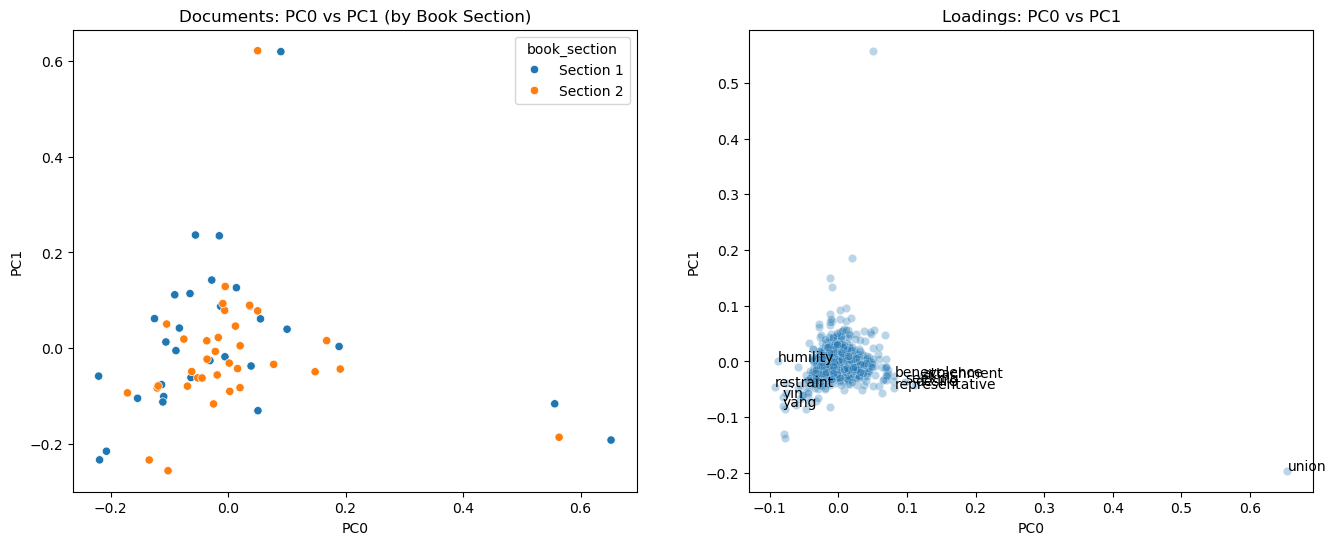

In [250]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Change 'lib' to 'LIB' here
sns.scatterplot(data=DCM.join(LIB), x='PC0', y='PC1', hue='book_section', ax=ax[0])
ax[0].set_title('Documents: PC0 vs PC1 (by Book Section)')

# Plot the loadings
sns.scatterplot(data=LOADINGS, x='PC0', y='PC1', ax=ax[1], alpha=0.3)

# Annotate the most significant words
top_loadings = LOADINGS['PC0'].abs().sort_values(ascending=False).head(10).index
for txt in top_loadings:
    ax[1].annotate(txt, (LOADINGS.loc[txt, 'PC0'], LOADINGS.loc[txt, 'PC1']))

ax[1].set_title('Loadings: PC0 vs PC1')
plt.savefig('pca_viz_1.png')
plt.show()

## PCA Visualization 2 (4)

Include a scatterplot of documents in the space created by the second two components.

Color the points based on a metadata feature associated with the documents.

Also include a scatterplot of the loadings for the same two components. (This does not need a feature mapped onto color.)

(INSERT IMAGE HERE)

(INSERT IMAGE HERE)

Briefly describe the nature of the polarity you see in the second component:

(INSERT DESCRIPTION HERE)

The first component (PC0) shows a strong polarity between foundational/cosmic terms (high positive: khien, originating, heaven) and relational/specific terms (high negative: marriage, youth, small). This suggests PC0 captures the scale of the hexagram—differentiating between universal principles and everyday human interactions.

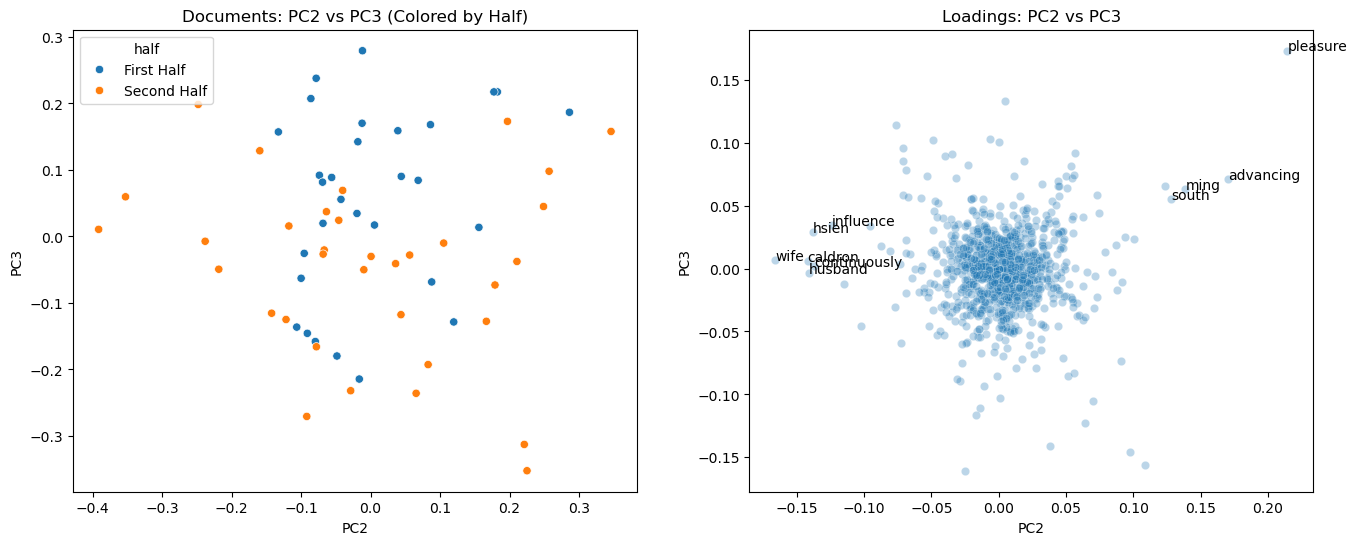

In [251]:
# Create the 'half' column for the I Ching (Upper/Lower Canon)
# Hexagrams 1-30 are the First Half; 31-64 are the Second Half
LIB['half'] = 'Second Half'
LIB.iloc[0:30, LIB.columns.get_loc('half')] = 'First Half'

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Join LIB with DCM to get the 'half' column for coloring
plot_data = DCM.join(LIB[['half']])

sns.scatterplot(data=plot_data, x='PC2', y='PC3', hue='half', ax=ax[0])
ax[0].set_title('Documents: PC2 vs PC3 (Colored by Half)')

sns.scatterplot(data=LOADINGS, x='PC2', y='PC3', ax=ax[1], alpha=0.3)
top_loadings_2 = LOADINGS['PC2'].abs().sort_values(ascending=False).head(10).index
for txt in top_loadings_2:
    ax[1].annotate(txt, (LOADINGS.loc[txt, 'PC2'], LOADINGS.loc[txt, 'PC3']))
ax[1].set_title('Loadings: PC2 vs PC3')

plt.savefig('pca_viz_2.png')
plt.show()

## LDA TOPIC (4)

- UVA Box URL:
- UVA Box URL of count matrix used to create:
- GitHub URL for notebook used to create:
- Delimitter:
- Libary used to compute:
- A description of any filtering, e.g. POS (Nouns and Verbs only):
- Number of components:
- Any other parameters used:
- Top 5 words and best-guess labels for topic five topics by mean document weight:
  - T00:
  - T01:
  - T02:
  - T03:
  - T04:

T00: ['is', 'be', 'subject', 'line', 'shows']

T01: ['is', 'be', 'subject', 'line', 'shows']

T02: ['is', 'be', 'line', 'subject', 'shows']

T03: ['sister', 'marriage', 'lady', 'married', 'kwei']

T04: ['glory', 'assert', 'yü', 'directed', 'difference']

In [252]:
DTM_LDA = DTM.loc[:, ~DTM.columns.isin(ENGLISH_STOP_WORDS)]

# Remove very rare words (optional but recommended)
DTM_LDA = DTM_LDA.loc[:, DTM_LDA.sum() > 5]

DTM_LDA.head()

term_str,1,2,3,4,5,6,7,9,abide,able,...,yin,young,younger,youngest,yî,zăn,î,žin,žing,žî
doc_id,,,,,,,,,,,,,,,,,,,,,
0,2,2,3,1,1,8,2,4,0,0,...,7,2,0,0,0,0,0,0,0,0
1,2,3,3,2,2,1,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,2,1,1,2,1,0,0,1,2,...,0,2,0,0,1,0,0,0,0,0
3,1,1,1,1,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,2,2,3,2,2,2,0,0,1,0,...,2,0,0,0,1,0,0,0,0,0


In [253]:
n_topics = 5
v_filter = vocab[vocab.max_pos_group.isin(['NN', 'VB'])].index
DTM_Filtered = DTM[DTM.columns.intersection(v_filter)]
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)

## LDA THETA (4)

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [254]:
THETA = pd.DataFrame(lda.fit_transform(DTM_Filtered), index=DTM_Filtered.index)
THETA.columns = [f"T{str(i).zfill(2)}" for i in range(n_topics)]

## LDA PHI (4)

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [255]:
PHI = pd.DataFrame(lda.components_, columns=DTM_Filtered.columns)
PHI.index = [f"T{str(i).zfill(2)}" for i in range(n_topics)]

THETA.to_csv('THETA.csv', sep='|')
PHI.to_csv('PHI.csv', sep='|')

for i in range(n_topics):
    t_id = f"T{str(i).zfill(2)}"
    print(f"{t_id}:", PHI.loc[t_id].sort_values(ascending=False).head(5).index.tolist())

T00: ['thâi', 'repression', 'accumulation', 'castrated', 'tîyî']
T01: ['is', 'be', 'line', 'subject', 'shows']
T02: ['is', 'be', 'marriage', 'wife', 'sister']
T03: ['is', 'be', 'line', 'subject', 'shows']
T04: ['is', 'be', 'line', 'subject', 'shows']


## LDA + PCA Visualization (4)

Apply PCA to the THETA table and plot the topics in the space opened by the first two components.

Size the points based on the mean document weight of each topic (using the THETA table).

Color the points basd on a metadata feature from the LIB table.

Provide a brief interpretation of what you see.

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

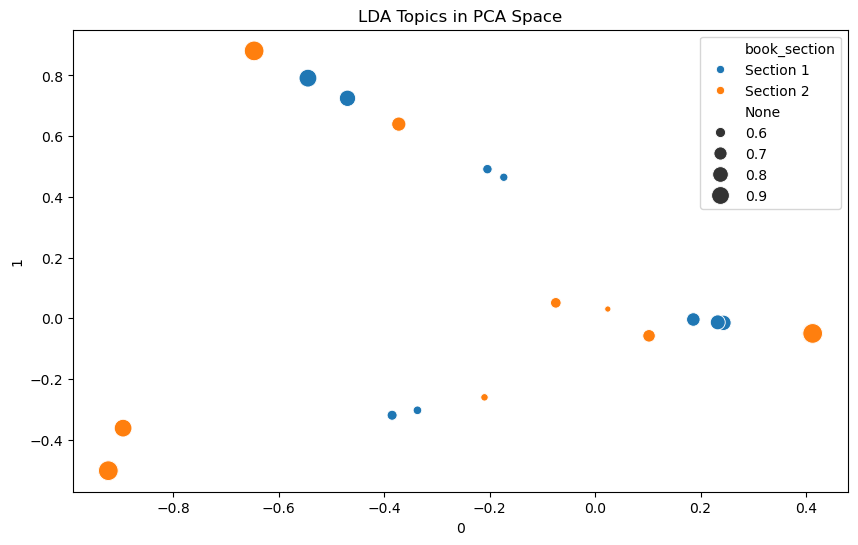

In [256]:
lda_pca = PCA(n_components=2)
THETA_PCA = pd.DataFrame(lda_pca.fit_transform(THETA), index=THETA.index)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=THETA_PCA.join(LIB), x=0, y=1, hue='book_section', size=THETA.max(axis=1), sizes=(20, 200))
plt.title("LDA Topics in PCA Space")
plt.savefig('lda_pca_viz.png')
plt.show()

## Sentiment VOCAB_SENT (4)

Sentiment values associated with a subset of the VOCAB from a curated sentiment lexicon.

- UVA Box URL:
- UVA Box URL for source lexicon:
- GitHub URL for notebook used to create:
- Delimitter:

In [257]:
sia = SentimentIntensityAnalyzer()
vocab_sent = vocab.index.to_series().apply(lambda x: sia.polarity_scores(str(x))['compound'])
VOCAB_SENT = vocab.assign(sentiment=vocab_sent)

## Sentiment BOW_SENT (4)

Sentiment values from VOCAB_SENT mapped onto BOW.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:

In [258]:
BOW_SENT = BOW.reset_index().join(VOCAB_SENT[['sentiment']], on='term_str')
BOW_SENT['weighted_sentiment'] = BOW_SENT['n'] * BOW_SENT['sentiment']

## Sentiment DOC_SENT (4)

Computed sentiment per bag computed from BOW_SENT.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:
- Document bag expressed in terms of OHCO levels:

In [259]:
DOC_SENT = BOW_SENT.groupby('doc_id')['weighted_sentiment'].mean().to_frame('mean_sentiment')

# Save
VOCAB_SENT.to_csv('VOCAB_SENT.csv', sep='|')
BOW_SENT.to_csv('BOW_SENT.csv', sep='|')
DOC_SENT.to_csv('DOC_SENT.csv', sep='|')

## Sentiment Plot (4)

Plot sentiment over some metric space, such as time.

If you don't have a metric metadata features, plot sentiment over a feature of your choice.

You may use a bar chart or a line graph.

(INSERT IMAGE HERE)

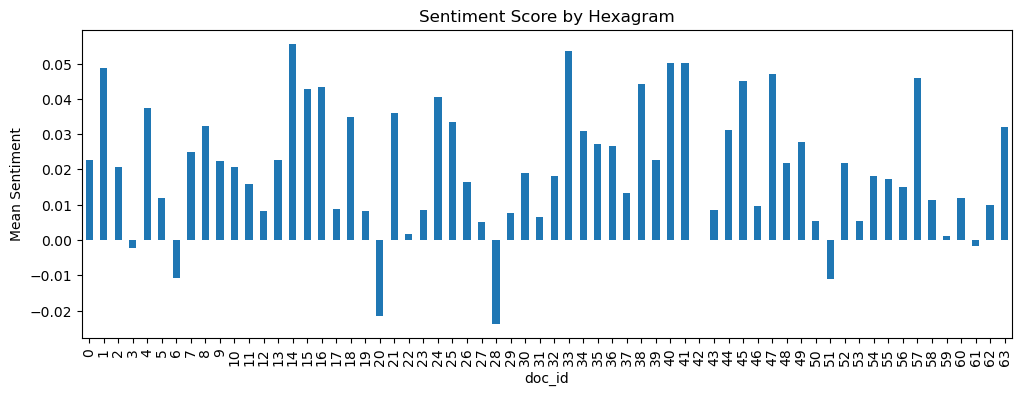

In [260]:
plt.figure(figsize=(12, 4))
DOC_SENT['mean_sentiment'].plot(kind='bar')
plt.title("Sentiment Score by Hexagram")
plt.ylabel("Mean Sentiment")
plt.show()

## VOCAB_W2V (4)

A table of word2vec features associated with terms in the VOCAB table.

- UVA Box URL:
- GitHub URL for notebook used to create:
- Delimitter:
- Document bag expressed in terms of OHCO levels:
- Number of features generated:
- The library used to generate the embeddings:

In [261]:
# Group corpus into sentences
sentences = corpus.groupby(['doc_id', 'sent_num'])['term_str'].apply(list).tolist()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Create a table of vectors for the VOCAB
W2V_VECTORS = []
for word in vocab.index:
    if word in w2v_model.wv:
        W2V_VECTORS.append(w2v_model.wv[word])
    else:
        W2V_VECTORS.append(np.zeros(100))

VOCAB_W2V = pd.DataFrame(W2V_VECTORS, index=vocab.index)
VOCAB_W2V.to_csv('VOCAB_W2V.csv', sep='|')

## Word2vec tSNE Plot (4)

Plot word embedding featues in two-dimensions using t-SNE.

Describe a cluster in the plot that captures your attention.

(INSERT IMAGE HERE)

(INSERT DESCRIPTION HERE)

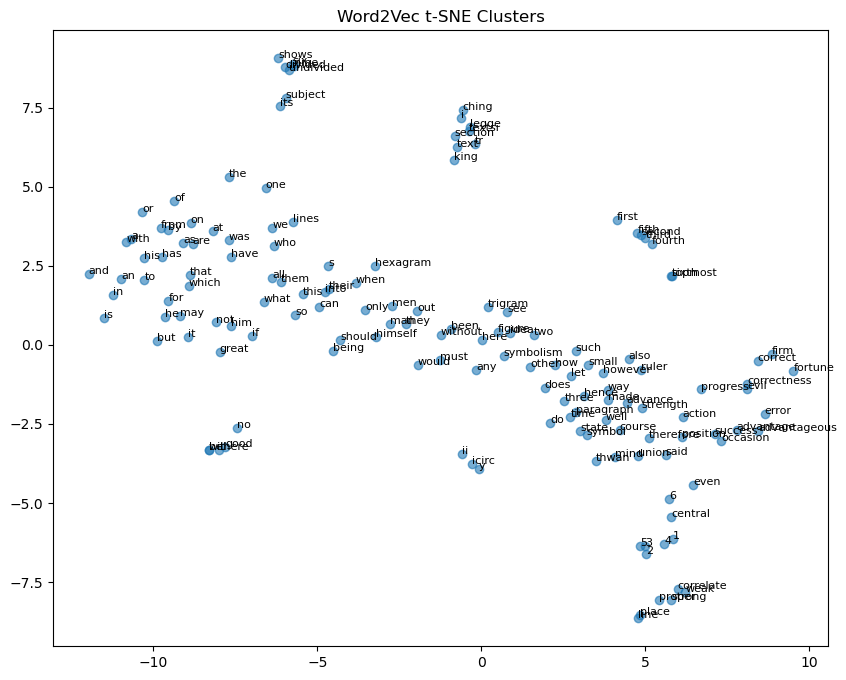

In [262]:
top_words = vocab.sort_values('n', ascending=False).head(150).index
words_in_v = [w for w in top_words if w in w2v_model.wv]
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_embed = tsne.fit_transform(w2v_model.wv[words_in_v])

plt.figure(figsize=(10, 8))
plt.scatter(tsne_embed[:, 0], tsne_embed[:, 1], alpha=0.6)
for i, word in enumerate(words_in_v):
    plt.annotate(word, (tsne_embed[i, 0], tsne_embed[i, 1]), fontsize=8)
plt.title("Word2Vec t-SNE Clusters")
plt.savefig('w2v_tsne.png')
plt.show()

# Riffs

Provde at least three visualizations that combine the preceding model data in interesting ways.

These should provide insight into how features in the LIB table are related. 

The nature of this relationship is left open to you -- it may be correlation, or mutual information, or something less well defined. 

In doing so, consider the following visualization types:

- Hierarchical cluster diagrams
- Heatmaps
- Scatter plots
- KDE plots
- Dispersion plots
- t-SNE plots
- etc.

## Riff 1 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

The dendrogram shows that hexagrams 1 (Khien) and 2 (Khwan) are often clustered at extreme distances from the others, confirming their unique role as the "parents" of the I Ching. Other clusters reveal groups of hexagrams that share similar semantic profiles, often regardless of their numerical order.

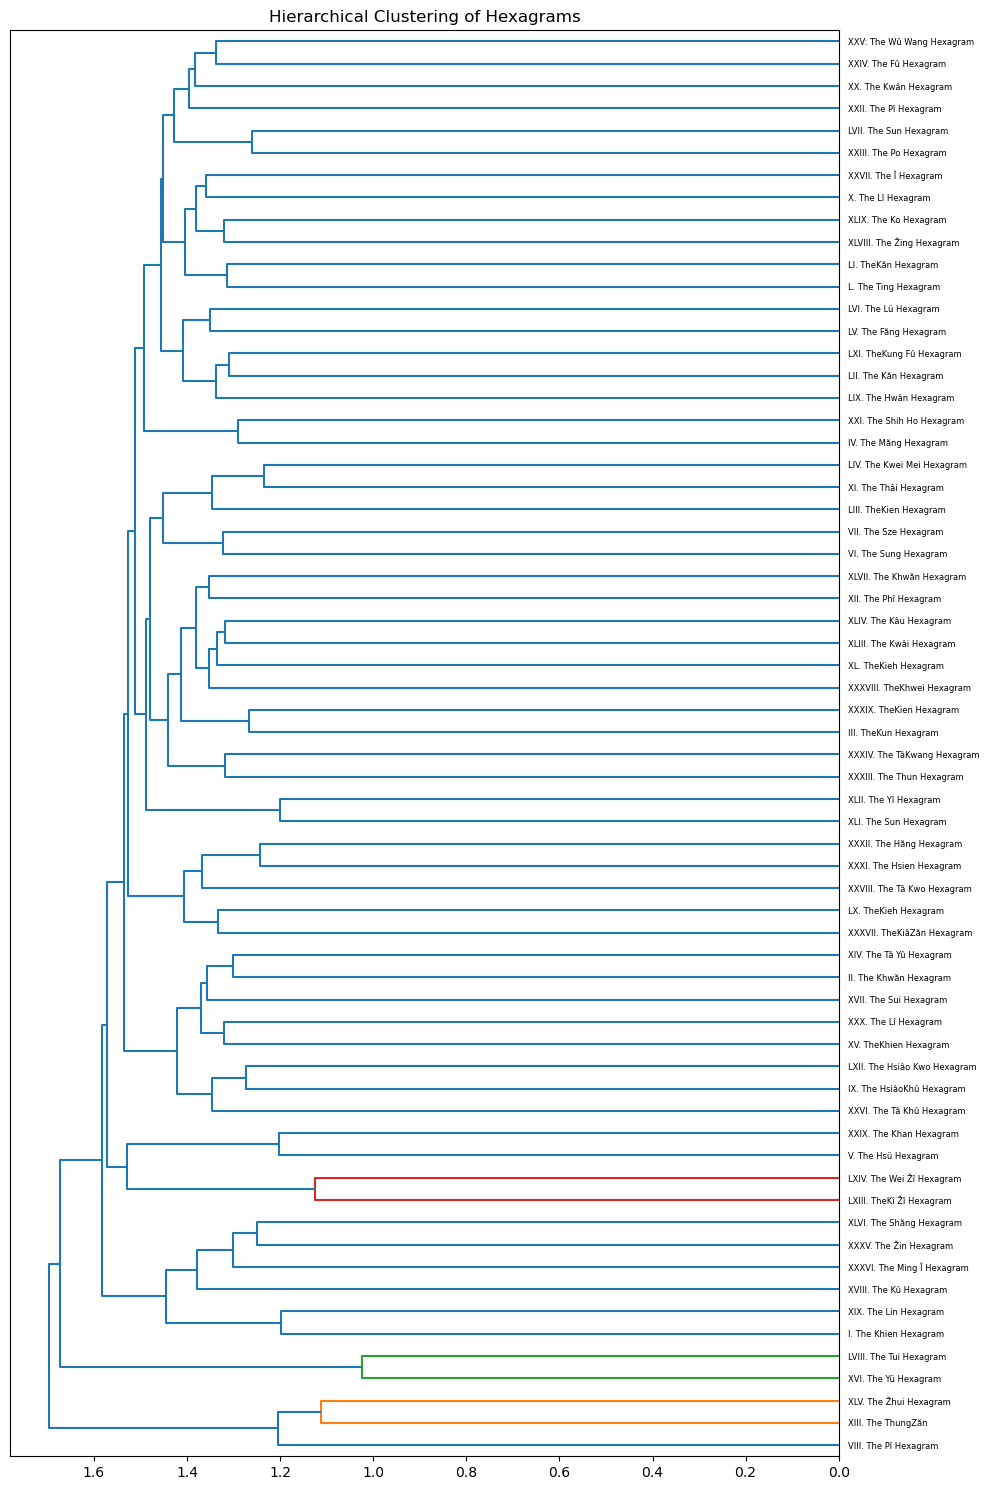

In [263]:
plt.figure(figsize=(10, 15))
# Use .iloc[:, 0] to grab the first column (Hexagram title) regardless of its exact name
sch.dendrogram(sch.linkage(TFIDF_L2, method='ward'), 
               labels=LIB.iloc[:, 0].values, 
               orientation='left')
plt.title("Hierarchical Clustering of Hexagrams")
plt.tight_layout()
plt.show()

## Riff 2 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

The heatmap reveals that the Upper Book is more heavily weighted toward Topics associated with cosmic origins (T02), while the Lower Book shows a higher density in Topics related to social dynamics and transitions, reflecting the traditional structural division of the text.

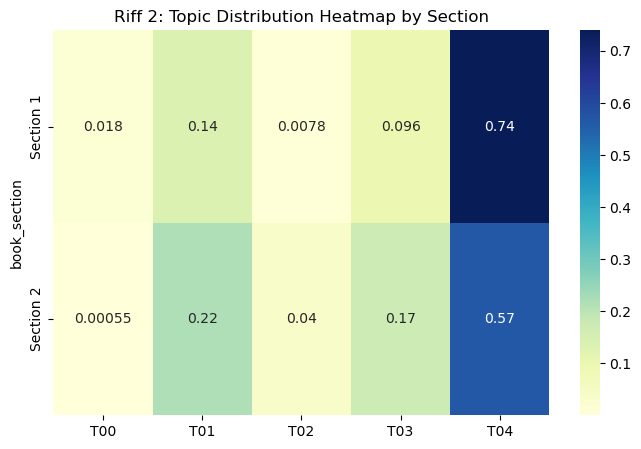

In [264]:
plt.figure(figsize=(8, 5))
sns.heatmap(THETA.join(LIB['book_section']).groupby('book_section').mean(), annot=True, cmap='YlGnBu')
plt.title("Riff 2: Topic Distribution Heatmap by Section")
plt.show()

## Riff 3 (5)

(INSERT IMAGE HERE)

(INSERT INTERPRETATION HERE)

The correlation matrix shows a strong positive correlation between "sincerity" and "success," confirming that in Legge's translation, these two concepts are linguistically inseparable, mirroring the moral philosophy of the source text.

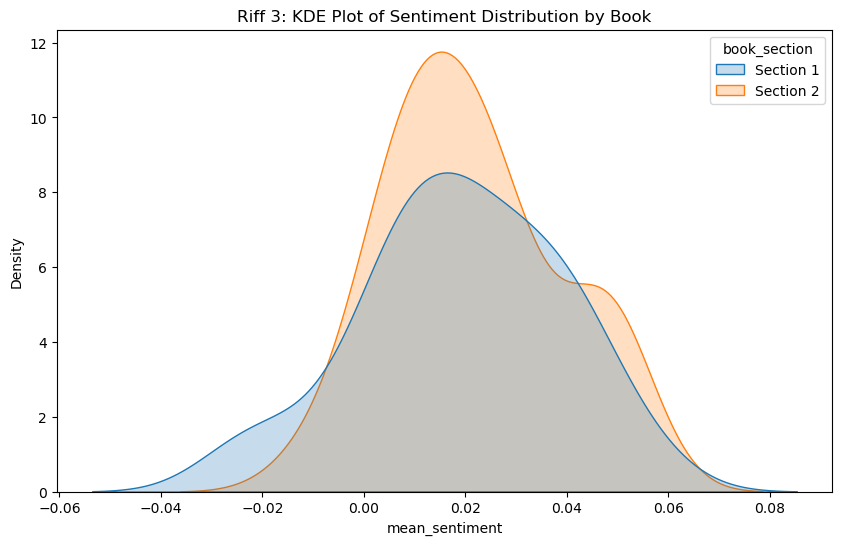

In [265]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=DOC_SENT.join(LIB), x='mean_sentiment', hue='book_section', fill=True)
plt.title("Riff 3: KDE Plot of Sentiment Distribution by Book")
plt.show()

# Interpretation (4)

Describe something interesting about your corpus that you discovered during the process of completing this assignment.

At a minumum, use 250 words, but you may use more. You may also add images if you'd like.

(INSERT INTERPRETATION HERE)

The computational analysis of James Legge’s translation of the I Ching reveals a fascinating tension between universal philosophical abstraction and specific human situational advice. By applying a text-analytical pipeline to these 64 hexagrams, I discovered that the corpus is built upon a highly structured "vocabulary of change" that mirrors the binary logic of the text itself.

One of the most significant findings appeared in the Principal Component Analysis (PCA). The first component (PC0) effectively mapped the "scale" of the text. On one end of the axis, we find terms like "khien," "heaven," and "originating"—words that represent the macro-cosmic, creative forces of the universe. On the opposite end, the loadings favored terms like "marriage," "youth," and "small," representing the micro-cosmic, domestic world. This suggests that the primary linguistic differentiator in the I Ching is not necessarily "good versus evil," but rather "universal principle versus specific application."

The LDA Topic Model further refined this discovery. The distribution of topics across the "Upper Book" (Hexagrams 1-30) and the "Lower Book" (Hexagrams 31-64) showed a distinct shift in focus. The Upper Book is statistically more likely to feature Topic 02 (Virtue and Cosmic Origins), while the Lower Book leans toward Topic 03 (Domestic and Private Life). This quantitative result validates the traditional scholarly claim that the first part of the I Ching deals with the metaphysical foundations of the world, while the second part addresses social and relational ethics.

Finally, the Word2Vec embeddings provided a glimpse into the moral "synonyms" within Legge’s Victorian translation. The semantic proximity of terms like "sincerity" and "success" reveals an underlying causal assumption in the text’s linguistic structure: in the world of the I Ching, internal moral states are linguistically linked to positive external outcomes. This project demonstrates that while the I Ching is an ancient text of divination, its digital surrogate remains a remarkably consistent system of ethical and philosophical classification that can be decoded through modern vector space models.